In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# by start positions

In [ ]:
def plot_paired_tracks(
    pairs,                    # list of (x_upper, x_lower)
    upper_len, lower_len,     # lengths of the two lines
    upper_label="Upper", lower_label="Lower",
    upper_tick_extra=None, lower_tick_extra=None,
    figsize=(15, 2.8), dot_size=12,
    line_kwargs=None, tick_kwargs=None, connect_kwargs=None
):
    pairs = np.asarray(pairs, dtype=float)
    if pairs.ndim != 2 or pairs.shape[1] != 2:
        raise ValueError("pairs must be an array-like of shape (n, 2) -> (x_upper, x_lower)")
    if upper_len <= 0 or lower_len <= 0:
        raise ValueError("upper_len and lower_len must be positive")

    scale = upper_len / lower_len
    x_u = pairs[:, 0]
    x_l = pairs[:, 1] * scale

    upper_ticks = np.unique(np.r_[x_u, [] if upper_tick_extra is None else upper_tick_extra])
    lower_ticks = np.unique(np.r_[pairs[:, 1], [] if lower_tick_extra is None else lower_tick_extra])
    lower_ticks_scaled = lower_ticks * scale

    line_kwargs = dict(color="black", lw=3, alpha=0.8) if line_kwargs is None else line_kwargs
    tick_kwargs = dict(color="black", lw=1.2, alpha=0.9) if tick_kwargs is None else tick_kwargs
    connect_kwargs = dict(color="gray", ls="--", lw=1.0, alpha=0.8) if connect_kwargs is None else connect_kwargs

    fig, ax = plt.subplots(figsize=figsize)

    ax.hlines(1, 0, upper_len, **line_kwargs)
    ax.hlines(0, 0, upper_len, **line_kwargs)

    ax.vlines(upper_ticks, 1-0.15, 1+0.15, **tick_kwargs)
    ax.vlines(lower_ticks_scaled, 0-0.15, 0+0.15, **tick_kwargs)

    ax.scatter(upper_ticks, np.full_like(upper_ticks, 1.0), s=dot_size, color="black", zorder=3)
    ax.scatter(lower_ticks_scaled, np.full_like(lower_ticks_scaled, 0.0), s=dot_size, color="black", zorder=3)

    for xu, xl in zip(x_u, x_l):
        ax.plot([xl, xu], [0, 1], **connect_kwargs)

    ax.text(-0.02*upper_len, 1, upper_label, ha="right", va="center", fontsize=14)
    ax.text(-0.02*upper_len, 0, lower_label, ha="right", va="center", fontsize=14)

    ax.set_xlim(0, upper_len)
    ax.set_ylim(-0.6, 1.6)
    ax.set_yticks([])

    ax.set_xlabel(f"Genomic position ({upper_label} units), bp", fontsize=14)

    secax = ax.secondary_xaxis('top', functions=(lambda x: x/scale, lambda x: x*scale))
    secax.set_xlabel(f"Genomic position ({lower_label} units), bp", fontsize=14)

    for side in ("left", "right", "top"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_alpha(0.3)
    ax.tick_params(axis='x', direction='out')

    plt.tight_layout()
    plt.show()





# X-Y regions with high similarity

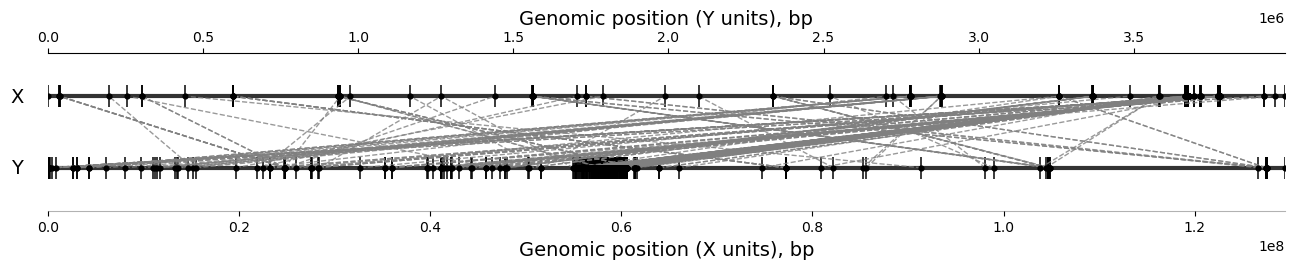

In [ ]:
y_len=3986568
x_len=129409743

basepath=""
df=pd.read_csv(f"{basepath}/BLAST/YX/homologous_regions.rY.qX.filt1e2_ident90_len10.csv", index_col=None, header=0, sep="\t")
pairs=[(r[1]["qstart"], r[1]["sstart"]) for r in df.iterrows() ]


plot_paired_tracks(
    pairs,
    x_len, y_len,
    upper_label="X", lower_label="Y",
    upper_tick_extra=[0, x_len], lower_tick_extra=[0, y_len],
    figsize=(13, 2.8)
)

# Xtrans genes on Y

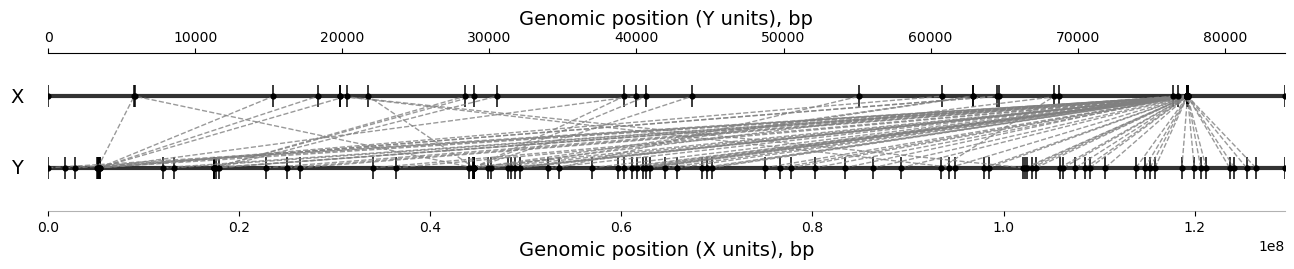

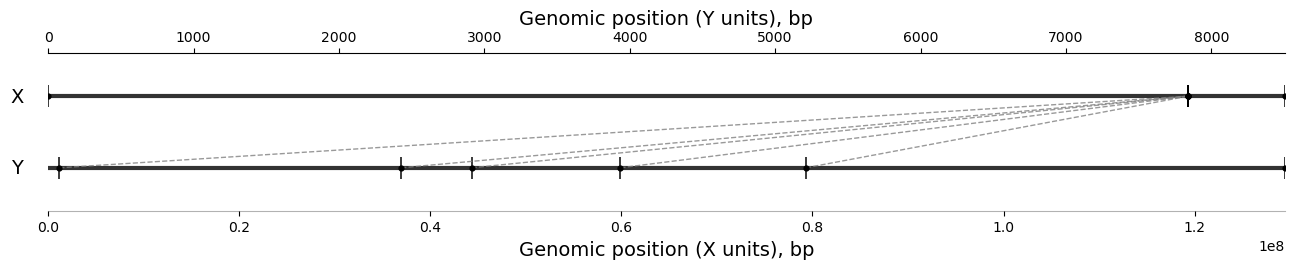

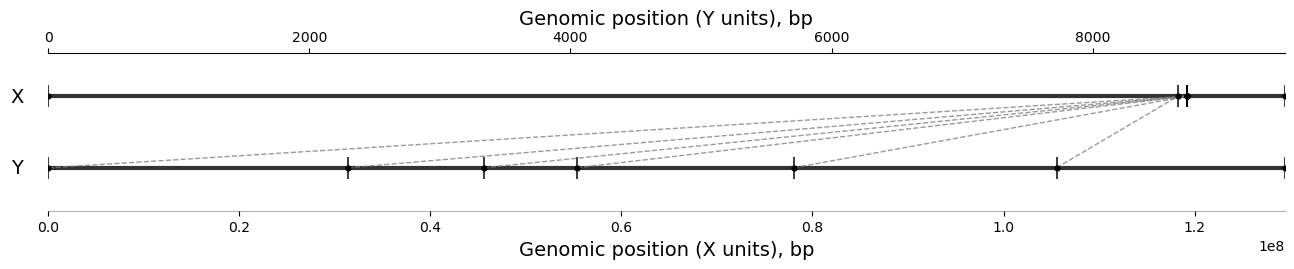

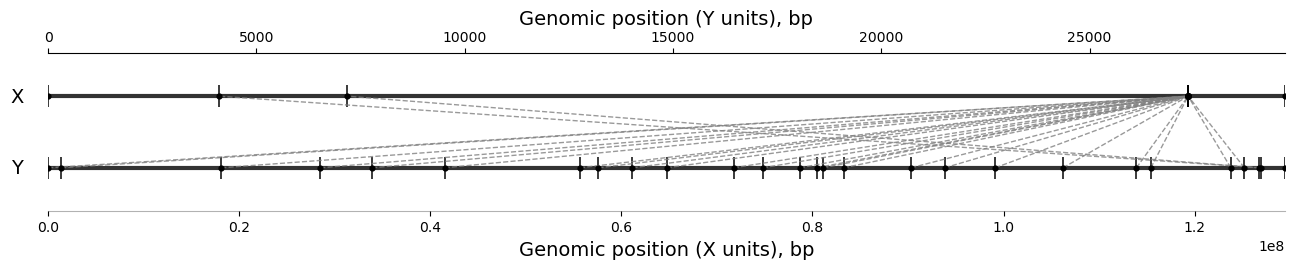

In [ ]:
x_len=129409743

df=pd.read_csv(f"{basepath}/Annotation/homologs.rY_Xtrans.qX.IDT50.W20.csv", index_col=None, header=None, sep="\t")
df.columns = ["qseqid","sseqid","pident","length","mismatch","gapopen","qstart","qend","sstart","send","evalue","bitscore"]

for loc in ["LOC113931451_1721160_1805221","LOC118356621_1821483_1829985",
            "LOC118356622_1767591_1777178","LOC118356649_1836509_1866215"]:
    df_loc = df[(df["sseqid"]==loc) & (df["pident"] > 90)]
    pairs=[(r[1]["qstart"], r[1]["sstart"]) for r in df_loc.iterrows() ]
    y_len = max(df_loc["send"])

    plot_paired_tracks(
        pairs,
        x_len, y_len,
        upper_label="X", lower_label="Y",
        upper_tick_extra=[0, x_len], lower_tick_extra=[min(df_loc["sstart"]), max(df_loc["send"])],
        figsize=(13, 2.8)
    )
    